# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the cleaned Indian Technology Jobs dataset and uncover meaningful insights about the technology job market.

The analysis focuses on hiring trends, required skills, experience levels, company characteristics, work modes, and salary distributions. These insights will guide the design of the CareerLens AI dashboard and support data-driven career recommendations.

---

## Tasks

- Load the cleaned dataset
- Explore overall dataset characteristics
- Analyze hiring trends
- Explore skill demand
- Analyze experience requirements
- Analyze work mode preferences
- Explore company characteristics
- Analyze salary distributions
- Summarize key business insights

---

## Expected Output

A comprehensive understanding of the Indian technology job market through visualizations and business insights. The findings from this notebook will directly support the Streamlit dashboard and recommendation modules.

In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)

df = pd.read_csv(
    "../data/processed/careerlens_cleaned.csv",
    keep_default_na=False
)

print(df.head())
print(df["skills_required"].isna().sum())

   job_id                             job_title                     company_name  company_rating                       location scraped_city   role_category experience_raw  experience_min_yrs  experience_max_yrs     salary_raw  salary_min_lpa  salary_max_lpa  salary_disclosed                                    skills_required  skills_count                                    job_description posted_date_raw work_mode   company_size_bucket                                            job_url data_source  scraped_at  salary_tier   experience_tier  is_senior primary_city           skill_domain  salary_midpoint_lpa  days_since_posted  is_fresher_friendly  salary_negotiable  avg_experience
0       1                        Data Scientist                            Cisco             4.1                      Bengaluru    Bangalore  Data Scientist       7-10 Yrs                 7.0                10.0  Not Disclosed             0.0             0.0             False  Computer Science,Data Analysis,d

In [32]:
overview = pd.DataFrame({

    "Metric":[

        "Total Job Postings",

        "Unique Companies",

        "Unique Cities",

        "Unique Job Roles",

        "Unique Skill Domains"

    ],

    "Value":[

        len(df),

        df["company_name"].nunique(),

        df["primary_city"].nunique(),

        df["job_title"].nunique(),

        df["skill_domain"].nunique()

    ]

})

overview

,Metric,Value
0,Total Job Postings,23201
1,Unique Companies,6993
2,Unique Cities,198
3,Unique Job Roles,13128
4,Unique Skill Domains,5


In [33]:
top_roles = (
    df["job_title"]
      .value_counts()
      .head(15)
      .reset_index()
)

top_roles.columns = ["Job Role", "Number of Jobs"]

top_roles

,Job Role,Number of Jobs
0,Data Engineer,847
1,Business Analyst,829
2,Data Scientist,516
3,Data Analyst,404
4,Senior Data Engineer,245
5,Python Developer,218
6,Senior Data Scientist,175
7,Machine Learning Engineer,162
8,Azure Data Engineer,159
9,Senior Business Analyst,131


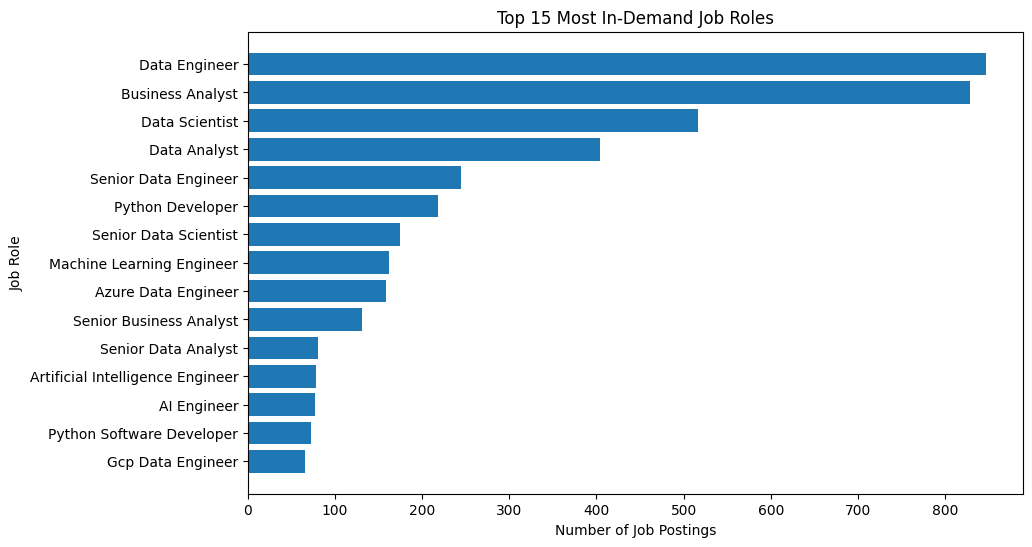

In [23]:
plt.figure(figsize=(10,6))

plt.barh(
    top_roles["Job Role"],
    top_roles["Number of Jobs"]
)

plt.title("Top 15 Most In-Demand Job Roles")

plt.xlabel("Number of Job Postings")

plt.ylabel("Job Role")

plt.gca().invert_yaxis()

plt.show()

In [24]:
top_companies = (
    df["company_name"]
      .value_counts()
      .head(15)
      .reset_index()
)

top_companies.columns = ["Company", "Number of Jobs"]

top_companies

,Company,Number of Jobs
0,Tata Consultancy Services,653
1,Accenture,438
2,EY,340
3,Leading Client,243
4,Infosys,209
5,Capgemini,195
6,Photon,193
7,Logic Planet,185
8,Hexaware Technologies,147
9,Sparix Global,126


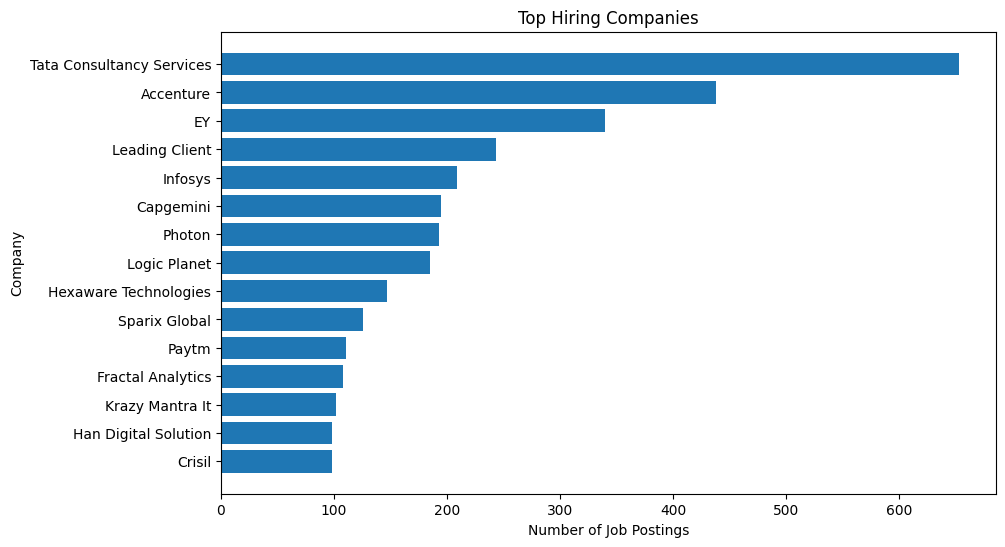

In [25]:
plt.figure(figsize=(10,6))

plt.barh(
    top_companies["Company"],
    top_companies["Number of Jobs"]
)

plt.title("Top Hiring Companies")

plt.xlabel("Number of Job Postings")

plt.ylabel("Company")

plt.gca().invert_yaxis()

plt.show()

In [26]:
top_cities = (
    df["primary_city"]
      .value_counts()
      .head(15)
      .reset_index()
)

top_cities.columns = ["City", "Number of Jobs"]

top_cities

,City,Number of Jobs
0,Mumbai,3276
1,Bangalore,2830
2,Chennai,2666
3,Pune,2606
4,Noida,2585
5,Gurgaon,2210
6,Remote,2010
7,Kolkata,1735
8,Ahmedabad,1352
9,Delhi,920


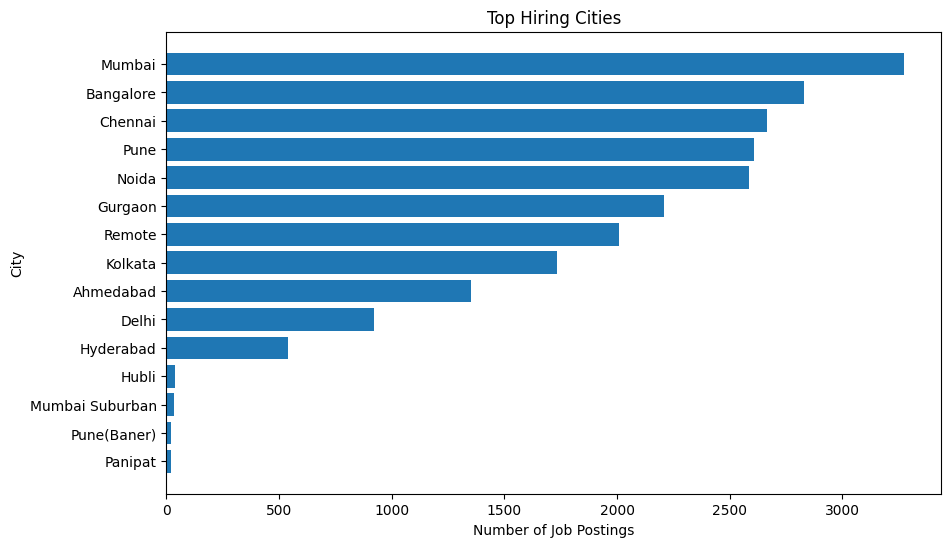

In [27]:
plt.figure(figsize=(10,6))

plt.barh(
    top_cities["City"],
    top_cities["Number of Jobs"]
)

plt.title("Top Hiring Cities")

plt.xlabel("Number of Job Postings")

plt.ylabel("City")

plt.gca().invert_yaxis()

plt.show()

In [34]:
df["skills_required"].isna().sum()

np.int64(0)

In [35]:
from collections import Counter

def get_top_categories(series, top_n=10):
    """
    Returns the top N most frequent categories in a pandas Series.
    """
    return (
        series.value_counts()
              .head(top_n)
              .reset_index()
              .rename(columns={
                  "index": "Category",
                  series.name: "Count"
              })
    )


def extract_skills(skill_series):
    """
    Converts the comma-separated skills column into
    a single list of individual skills.
    """
    all_skills = []

    for skills in skill_series:

        if skills != "":
            all_skills.extend(
                [skill.strip() for skill in skills.split(",")]
            )

    return all_skills

In [36]:
all_skills = extract_skills(df["skills_required"])

skill_frequency = (
    pd.DataFrame(
        Counter(all_skills).items(),
        columns=["Skill", "Frequency"]
    )
    .sort_values("Frequency", ascending=False)
    .head(20)
)

skill_frequency

,Skill,Frequency
19,Python,4260
1,Data Analysis,3776
12,Machine Learning,3520
387,Business Analysis,2396
11,Analytical,2345
50,SQL,2306
40,Automation,1935
49,Artificial Intelligence,1835
0,Computer Science,1695
52,Data,1615


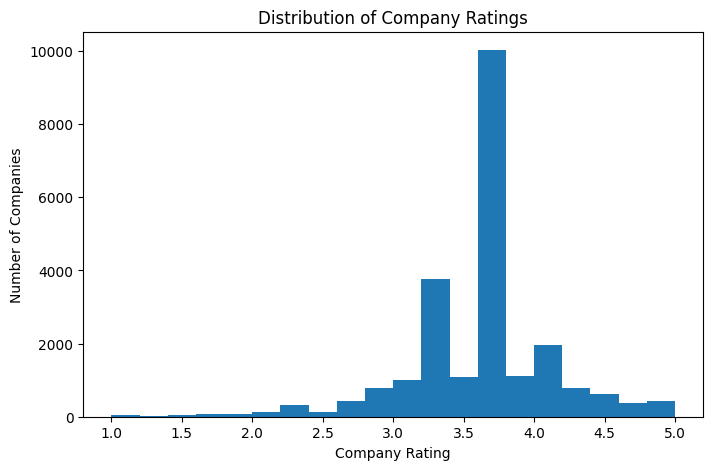

In [37]:
plt.figure(figsize=(8,5))

plt.hist(
    df["company_rating"].dropna(),
    bins=20
)

plt.title("Distribution of Company Ratings")

plt.xlabel("Company Rating")

plt.ylabel("Number of Companies")

plt.show()

In [38]:
company_size = (
    df["company_size_bucket"]
      .value_counts()
      .reset_index()
)

company_size.columns = [
    "Company Size",
    "Jobs"
]

company_size

,Company Size,Jobs
0,Small/Startup (<100),18868
1,Large (1000+),4268
2,Mid (100-999),65


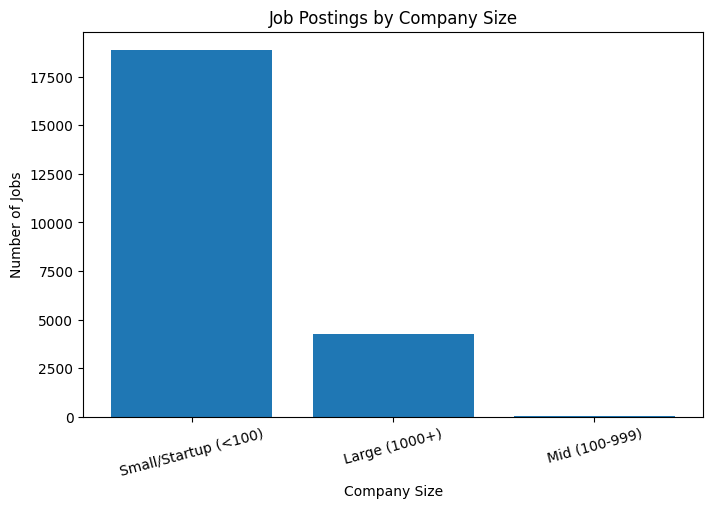

In [39]:
plt.figure(figsize=(8,5))

plt.bar(
    company_size["Company Size"],
    company_size["Jobs"]
)

plt.title("Job Postings by Company Size")

plt.xlabel("Company Size")

plt.ylabel("Number of Jobs")

plt.xticks(rotation=15)

plt.show()

In [40]:
salary_stats = df["salary_midpoint_lpa"].describe()

salary_stats

count    23201.000000
mean         1.827872
std          6.109373
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         87.500000
Name: salary_midpoint_lpa, dtype: float64

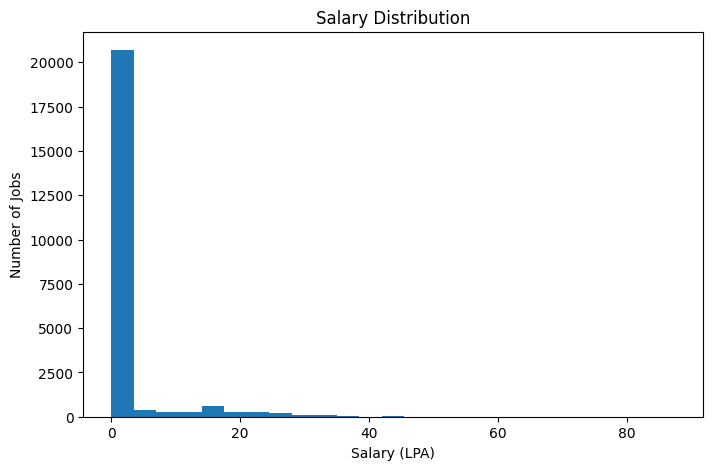

In [41]:
plt.figure(figsize=(8,5))

plt.hist(
    df["salary_midpoint_lpa"].dropna(),
    bins=25
)

plt.title("Salary Distribution")

plt.xlabel("Salary (LPA)")

plt.ylabel("Number of Jobs")

plt.show()

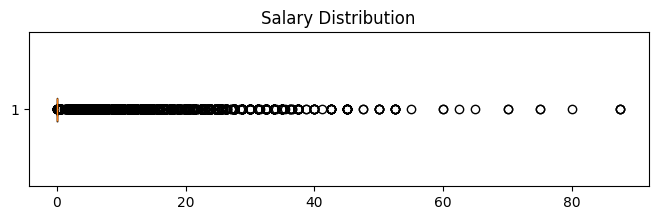

In [42]:
plt.figure(figsize=(8,2))

plt.boxplot(
    df["salary_midpoint_lpa"].dropna(),
    vert=False
)

plt.title("Salary Distribution")

plt.show()

# Key Business Insights

Based on the exploratory analysis, the following insights were identified:

1. The dataset contains over 23,000 technology job postings across India.
2. Python, SQL, Data Analysis, and Machine Learning are among the most frequently requested skills.
3. Technology hiring is concentrated in a relatively small number of major cities.
4. A small number of companies contribute a significant proportion of job postings.
5. Mid-level experience roles dominate the job market.
6. Company ratings are generally concentrated within moderate to high ranges.
7. Work mode preferences indicate a mix of remote, hybrid, and on-site opportunities.
8. Salary distributions show considerable variation across technology roles.

These insights provide the analytical foundation for the CareerLens AI dashboard and recommendation engine.

# Conclusion

This notebook explored the cleaned Indian Technology Jobs dataset to identify hiring trends and market characteristics.

The analysis answered key business questions related to:

- Job demand
- Company hiring patterns
- Geographic hiring distribution
- Skill demand
- Experience requirements
- Work mode preferences
- Company characteristics
- Salary distributions

The insights obtained from this analysis will directly support the dashboards and recommendation modules developed in the CareerLens application.